# Solución Actividad de Seguimiento 4
- Jose David Román
- Wendy Ortega
- Juan Cuadro

Este estudio evalúa si es posible predecir la **temperatura oral** (`aveOralM`) de un paciente a partir de:
- `T_Max3`: Temperatura máxima del rostro medida con termografía infrarroja.
- `T_atm`: Temperatura ambiental durante la medición.
- `Humidity`: Humedad ambiental durante la medición.

# Análisis Exploratorio de Datos

# Carga de librerías y datos


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# Carga del archivo
df = pd.read_excel('temperaturas.xlsx')

print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Variables: {df.columns.tolist()}')
df.head(10)

Dimensiones del dataset: 1020 filas × 4 columnas
Variables: ['T_Max3', 'T_atm', 'Humidity', 'aveOralM']


,T_Max3,T_atm,Humidity,aveOralM
0,35.48,24.0,28.0,36.59
1,35.14,24.0,26.0,37.19
2,35.75,24.0,26.0,37.34
3,35.77,24.0,27.0,37.09
4,35.72,24.0,27.0,37.04
5,35.76,24.0,26.0,36.99
6,35.64,24.0,31.0,36.59
7,35.71,25.0,30.0,36.49
8,35.76,25.0,30.0,36.59
9,36.21,26.0,31.0,36.89


# Análisis Exploratorio de Datos

Se hace con el fin de comprender: 
- La distribución de las variables
- Detectar posibles anomalías

In [35]:
print('=== Estadísticos Descriptivos ===')
df.describe().round(4)

=== Estadísticos Descriptivos ===


,T_Max3,T_atm,Humidity,aveOralM
count,1010.0000,1020.0000,1020.0000,1020.0000
mean,35.9839,24.1154,28.7230,37.0284
std,0.5102,1.3363,13.0716,0.5095
min,34.8100,20.2000,9.9000,35.5400
25%,35.6600,23.4000,17.6000,36.7775
50%,35.9100,24.0000,26.3000,36.9400
75%,36.2000,24.7000,36.2000,37.1400
max,38.4100,29.1000,61.2000,40.3400


Podemos observar que...
- `T_Max3`: Temperatura termográfica máxima del rostro. Media ≈ 35.98 °C, con rango entre 34.81 y 38.41 °C.
- `T_atm`: Temperatura ambiental. Media ≈ 24.11 °C, con desviación estandar baja (std ≈ 1.34).
- `Humidity`: Humedad ambiental. Media ≈ 28.72%, con mayor desviación estandar (std ≈ 13.07).
- `aveOralM`: Temperatura oral (que será nuestra variable de respuesta). Media ≈ 37.03 °C, rango 35.54–40.34 °C.

Se nota que `T_Max3` tiene 10 valores faltantes. Por lo tanto debemos reemplazar estos datos nulos por la media de `T_Max3`

# Tratamiento de datos faltantes

In [36]:
print('=== Datos faltantes por variable ===')
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
print(resumen_nulos)

# Reemplazar nulos de forma segura
for col in df.columns:
    if df[col].isnull().sum() > 0:
        media_col = df[col].mean()
        # Asignación directa para evitar problemas de "inplace"
        df[col] = df[col].fillna(media_col)
        print(f'→ {col}: nulos corregidos.')

# Luego procedes con el cálculo de la diferencia y limpieza de outliers

print(f'\nDatos faltantes tras reemplazar nulos por la media: {df.isnull().sum().sum()}')
print(f'Dimensiones actuales: {df.shape}')

=== Datos faltantes por variable ===
          Nulos  Porcentaje (%)
T_Max3       10            0.98
T_atm         0            0.00
Humidity      0            0.00
aveOralM      0            0.00
→ T_Max3: nulos corregidos.

Datos faltantes tras reemplazar nulos por la media: 0
Dimensiones actuales: (1020, 4)


Ahora hacemos un gráfico de cajas y bigotes para ver su media, Datos atipicos y percentiles Q1,Q2 y Q3; de T_Max3 y aveOralM devido a que estas son las variables que debemos verificar si fueron correctamente medidas.


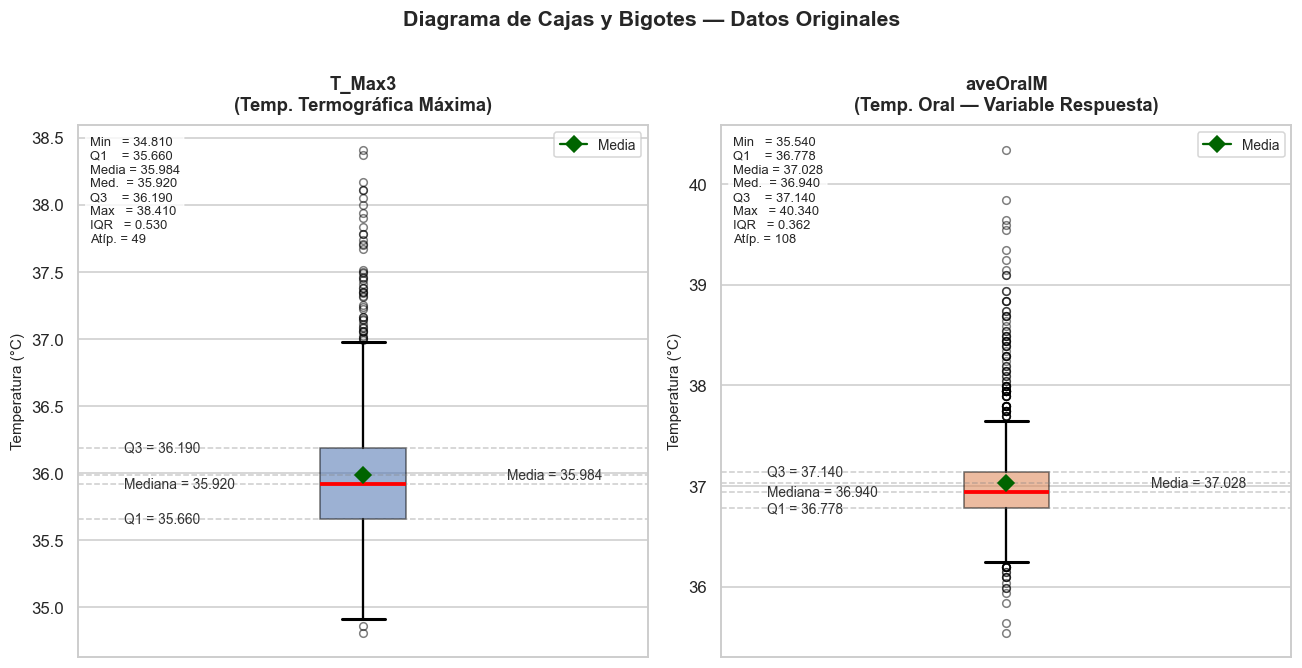

In [37]:
# Diagrama de cajas y bigotes para T_Max3 y aveOralM
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

variables = ['T_Max3', 'aveOralM']
colores   = ['#4C72B0', '#DD8452']
etiquetas = ['T_Max3\n(Temp. Termográfica Máxima)', 'aveOralM\n(Temp. Oral — Variable Respuesta)']

for ax, var, color, etiq in zip(axes, variables, colores, etiquetas):
    datos = df[var].dropna()
    bp = ax.boxplot(
        datos,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.55),
        medianprops=dict(color='red', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=2),
        flierprops=dict(marker='o', color='black', alpha=0.5, markersize=5)
    )

    Q1  = datos.quantile(0.25)
    Q2  = datos.quantile(0.50)
    Q3  = datos.quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high= Q3 + 1.5 * IQR
    media = datos.mean()

    # Anotaciones de estadísticos
    for val, lbl, halign in [
        (Q1,    f'Q1 = {Q1:.3f}',    'left'),
        (Q2,    f'Mediana = {Q2:.3f}','left'),
        (Q3,    f'Q3 = {Q3:.3f}',    'left'),
        (media, f'Media = {media:.3f}','right'),
    ]:
        ax.axhline(val, color='gray', linestyle='--', alpha=0.4, linewidth=1)
        ax.text(1.42 if halign == 'right' else 0.58, val, lbl,
                ha=halign, va='center', fontsize=9, color='#333333')

    # Punto de la media
    ax.plot(1, media, marker='D', color='darkgreen', markersize=7,
            zorder=5, label='Media')

    # Contar outliers
    n_out = ((datos < low) | (datos > high)).sum()

    ax.set_title(etiq, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Temperatura (°C)', fontsize=10)
    ax.set_xticks([])
    ax.legend(fontsize=9)

    # Estadísticos en caja de texto
    stats_txt = (f'Min   = {datos.min():.3f}\n'
                 f'Q1    = {Q1:.3f}\n'
                 f'Media = {media:.3f}\n'
                 f'Med.  = {Q2:.3f}\n'
                 f'Q3    = {Q3:.3f}\n'
                 f'Max   = {datos.max():.3f}\n'
                 f'IQR   = {IQR:.3f}\n'
                 f'Atíp. = {n_out}')
    ax.text(0.02, 0.98, stats_txt, transform=ax.transAxes,
            fontsize=8.5, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('Diagrama de Cajas y Bigotes — Datos Originales', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

En este diagrama podemos ver...

Ambas variables muestran datos atípicos (outliers) identificados como puntos fuera de los bigotes (más allá de Q1 - 1.5·IQR y Q3 + 1.5·IQR). Sin embargo, un outlier en temperatura corporal no necesariamente es un error: una persona con fiebre muy alta puede generar una temperatura oral elevada.



# Detección y eliminación de datos atípicos mediante la diferencia T_Max3 − aveOralM

### Justificación del método

Un valor extremo en `T_Max3` o en `aveOralM` de forma individual no es necesariamente un error: existen pacientes con fiebre alta. Sin embargo, si la diferencia entre ambas mediciones es muy significativa, indica una inconsistencia entre el termógrafo y el termómetro oral para ese mismo sujeto, lo cual sugiere un error de medición.

Por esta razón, no se eliminan outliers de cada variable por separado. de este modo la diferencia es:
`Diferencia = T_Max3 − aveOralM`

Luego se aplica el criterio IQR estándar sobre esta diferencia:
- Límite inferior: Q1 − 1.5 × IQR
- Límite superior: Q3 + 1.5 × IQR

Las filas cuya diferencia quede fuera de estos límites se eliminarán por representar inconsistencias entre los dos métodos de medición.

In [38]:
# Calcular la diferencia
df['Diferencia'] = df['T_Max3'] - df['aveOralM']

Q1_d  = df['Diferencia'].quantile(0.25)
Q3_d  = df['Diferencia'].quantile(0.75)
IQR_d = Q3_d - Q1_d
low_d = Q1_d - 1.5 * IQR_d
high_d= Q3_d + 1.5 * IQR_d

print(f'Estadísticos de la Diferencia (T_Max3 - aveOralM):')
print(f'  Q1    = {Q1_d:.4f}')
print(f'  Q3    = {Q3_d:.4f}')
print(f'  IQR   = {IQR_d:.4f}')
print(f'  Límite inferior = {low_d:.4f}')
print(f'  Límite superior = {high_d:.4f}')

mascara_out = (df['Diferencia'] < low_d) | (df['Diferencia'] > high_d)
outliers_df = df[mascara_out]
print(f'\nFilas identificadas como atípicas: {len(outliers_df)}')
print('Índices:', outliers_df.index.tolist())
outliers_df[['T_Max3', 'aveOralM', 'Diferencia']]

Estadísticos de la Diferencia (T_Max3 - aveOralM):
  Q1    = -1.2625
  Q3    = -0.8400
  IQR   = 0.4225
  Límite inferior = -1.8963
  Límite superior = -0.2062

Filas identificadas como atípicas: 13
Índices: [1, 22, 122, 150, 329, 514, 591, 636, 645, 674, 741, 845, 957]


,T_Max3,aveOralM,Diferencia
1,35.140000,37.19,-2.050000
22,35.983911,36.14,-0.156089
122,38.370000,40.34,-1.970000
150,35.840000,37.99,-2.150000
329,36.330000,36.49,-0.160000
514,36.600000,36.74,-0.140000
591,36.740000,36.94,-0.200000
636,36.810000,36.94,-0.130000
645,37.940000,39.84,-1.900000
674,36.020000,35.54,0.480000


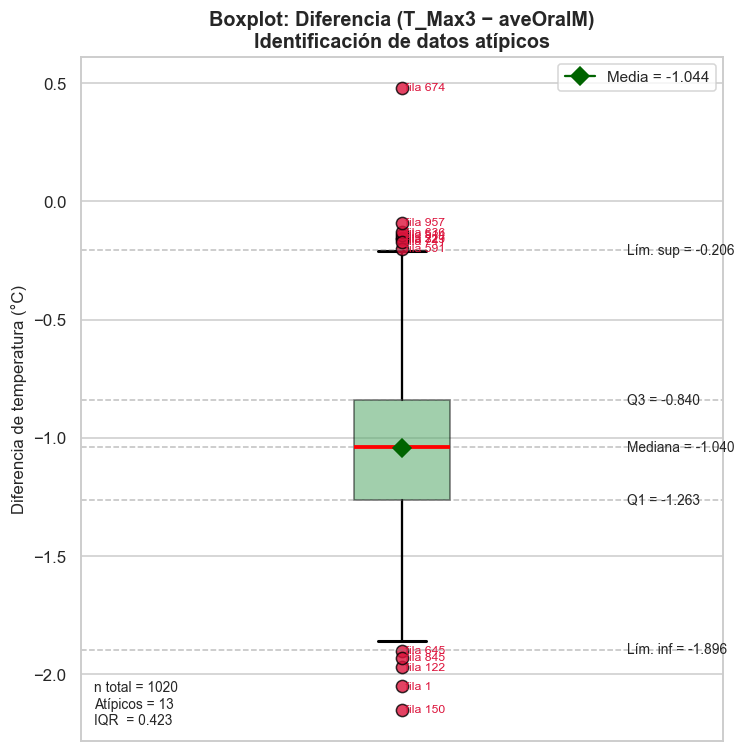

In [39]:
# Boxplot de la Diferencia con identificación de outliers
fig, ax = plt.subplots(figsize=(7, 7))

bp = ax.boxplot(
    df['Diferencia'],
    patch_artist=True,
    boxprops=dict(facecolor='#55A868', alpha=0.55),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=2),
    flierprops=dict(marker='o', color='crimson', markersize=8,
                    markerfacecolor='crimson', alpha=0.8)
)

Q2_d   = df['Diferencia'].median()
media_d = df['Diferencia'].mean()

for val, lbl in [
    (Q1_d,   f'Q1 = {Q1_d:.3f}'),
    (Q2_d,   f'Mediana = {Q2_d:.3f}'),
    (Q3_d,   f'Q3 = {Q3_d:.3f}'),
    (low_d,  f'Lím. inf = {low_d:.3f}'),
    (high_d, f'Lím. sup = {high_d:.3f}'),
]:
    ax.axhline(val, linestyle='--', color='gray', alpha=0.5, linewidth=1)
    ax.text(1.35, val, lbl, ha='left', va='center', fontsize=9)

ax.plot(1, media_d, marker='D', color='darkgreen', markersize=8,
        zorder=5, label=f'Media = {media_d:.3f}')

# Anotar outliers con su índice
for idx in outliers_df.index:
    val = df.loc[idx, 'Diferencia']
    ax.annotate(f' fila {idx}', xy=(1, val), fontsize=8, color='crimson',
                va='center')

ax.set_title('Boxplot: Diferencia (T_Max3 − aveOralM)\nIdentificación de datos atípicos', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Diferencia de temperatura (°C)', fontsize=11)
ax.set_xticks([])
ax.legend(fontsize=10)

stats_txt = (f'n total = {len(df)}\n'
             f'Atípicos = {len(outliers_df)}\n'
             f'IQR  = {IQR_d:.3f}')
ax.text(0.02, 0.02, stats_txt, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Con los indices de datos atípicos ya determinados, eliminamos dichas filas de nuestra base de datos

In [41]:
# Eliminar filas atípicas y la columna auxiliar
df_clean = df[~mascara_out].drop(columns=['Diferencia']).reset_index(drop=True)

print(f'Filas eliminadas   : {len(df) - len(df_clean)}')
print(f'Dimensiones finales de nustra base de datos: {df_clean.shape}')
df_clean.describe().round(4)

Filas eliminadas   : 13
Dimensiones finales de nustra base de datos: (1007, 4)


,T_Max3,T_atm,Humidity,aveOralM
count,1007.0000,1007.0000,1007.0000,1007.0000
mean,35.9755,24.1110,28.7241,37.0229
std,0.4962,1.3343,13.0941,0.4842
min,34.8100,20.2000,9.9000,35.6400
25%,35.6600,23.4000,17.6000,36.7900
50%,35.9100,24.0000,26.3000,36.9400
75%,36.1900,24.7000,36.2000,37.1400
max,38.4100,29.1000,61.2000,39.6400



Identificamos  13 filas donde la diferencia entre la temperatura termográfica (`T_Max3`) y la temperatura oral (`aveOralM`) era inusualmente grande o pequeña. Estas discrepancias no pueden explicarse por condiciones clínicas reales (la diferencia entre ambas medidas del mismo individuo debería ser relativamente constante), por lo que se concluye que corresponden a _**errores de medición o registro**_.

Tras la limpieza, nuestra base de datos queda con 1007 filas para el análisis de correlación y modelado.

# Distribución de las variables tras limpieza

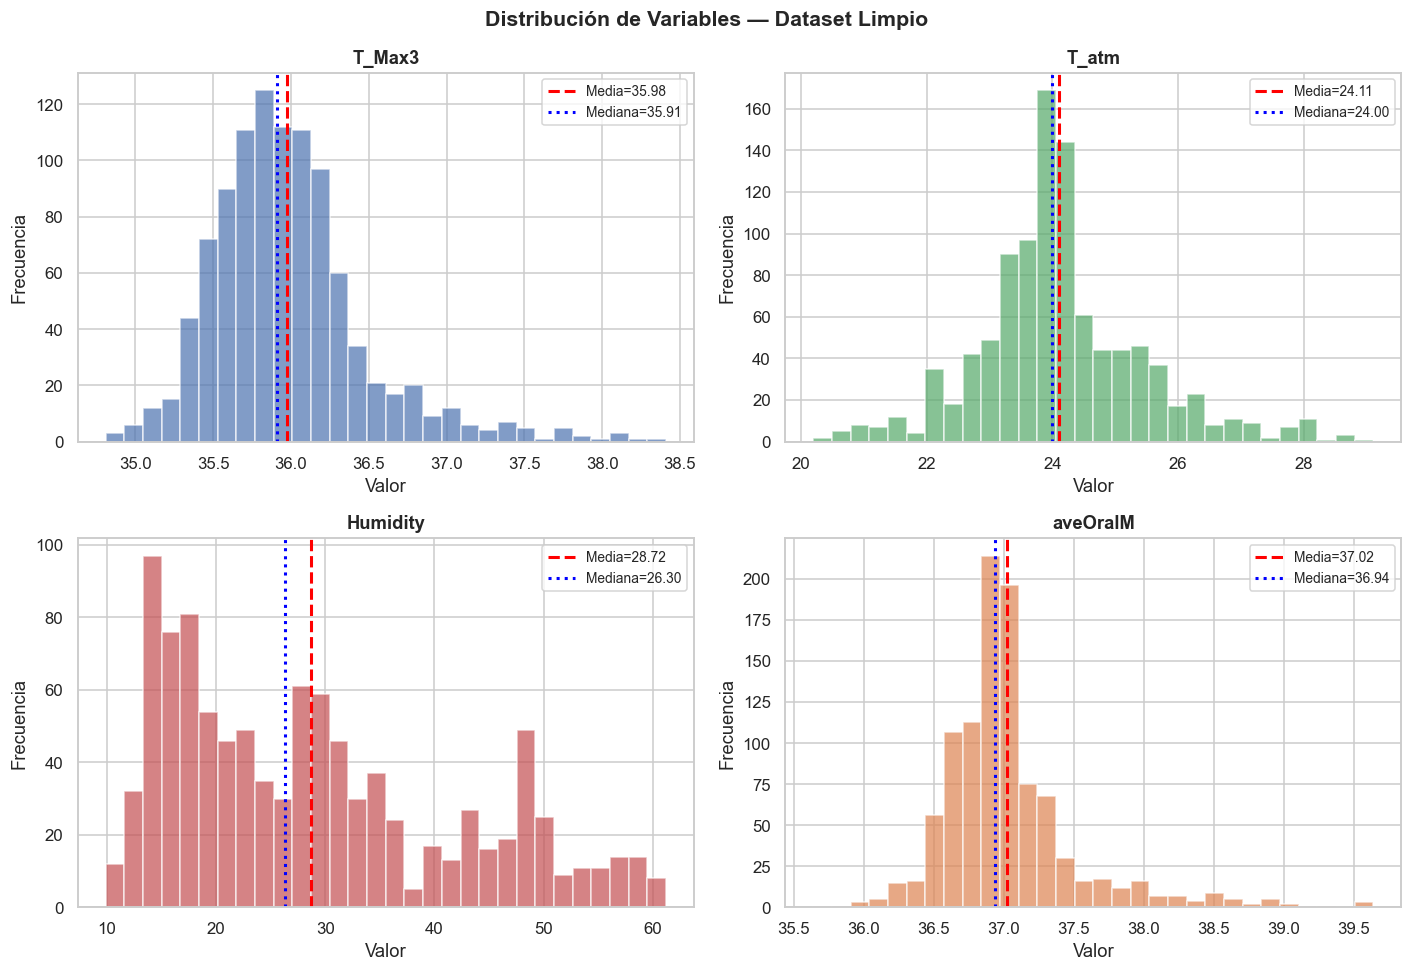

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
vars_plot  = ['T_Max3', 'T_atm', 'Humidity', 'aveOralM']
colores_h  = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

for ax, var, col in zip(axes.flat, vars_plot, colores_h):
    ax.hist(df_clean[var], bins=30, color=col, alpha=0.7, edgecolor='white')
    ax.axvline(df_clean[var].mean(),   color='red',  linestyle='--', lw=2, label=f'Media={df_clean[var].mean():.2f}')
    ax.axvline(df_clean[var].median(), color='blue', linestyle=':',  lw=2, label=f'Mediana={df_clean[var].median():.2f}')
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

fig.suptitle('Distribución de Variables — Dataset Limpio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Al observar las distribuciones de cada variable, vemos que `T_Max3`, `T_atm` y `aveOralM` muestran una distribución normal. Mientras que `Humidity` tiene una distribución anormal, confirmando que tiene mucha dispersión en sus datos.

# Matriz de Correlación

La matriz de correlación que nos permite cuantificar el grado de relación lineal entre las variables predictoras y la variable respuesta `aveOralM`.

In [42]:
corr = df_clean.corr()

print('=== Matriz de Correlación de Pearson ===')
print(corr.round(4))
print()

print('=== Correlación con aveOralM (variable respuesta) ===')
print(corr['aveOralM'].drop('aveOralM').sort_values(ascending=False).round(4))

=== Matriz de Correlación de Pearson ===
          T_Max3   T_atm  Humidity  aveOralM
T_Max3    1.0000  0.2766    0.0627    0.8120
T_atm     0.2766  1.0000    0.1177    0.1161
Humidity  0.0627  0.1177    1.0000    0.0651
aveOralM  0.8120  0.1161    0.0651    1.0000

=== Correlación con aveOralM (variable respuesta) ===
T_Max3      0.8120
T_atm       0.1161
Humidity    0.0651
Name: aveOralM, dtype: float64


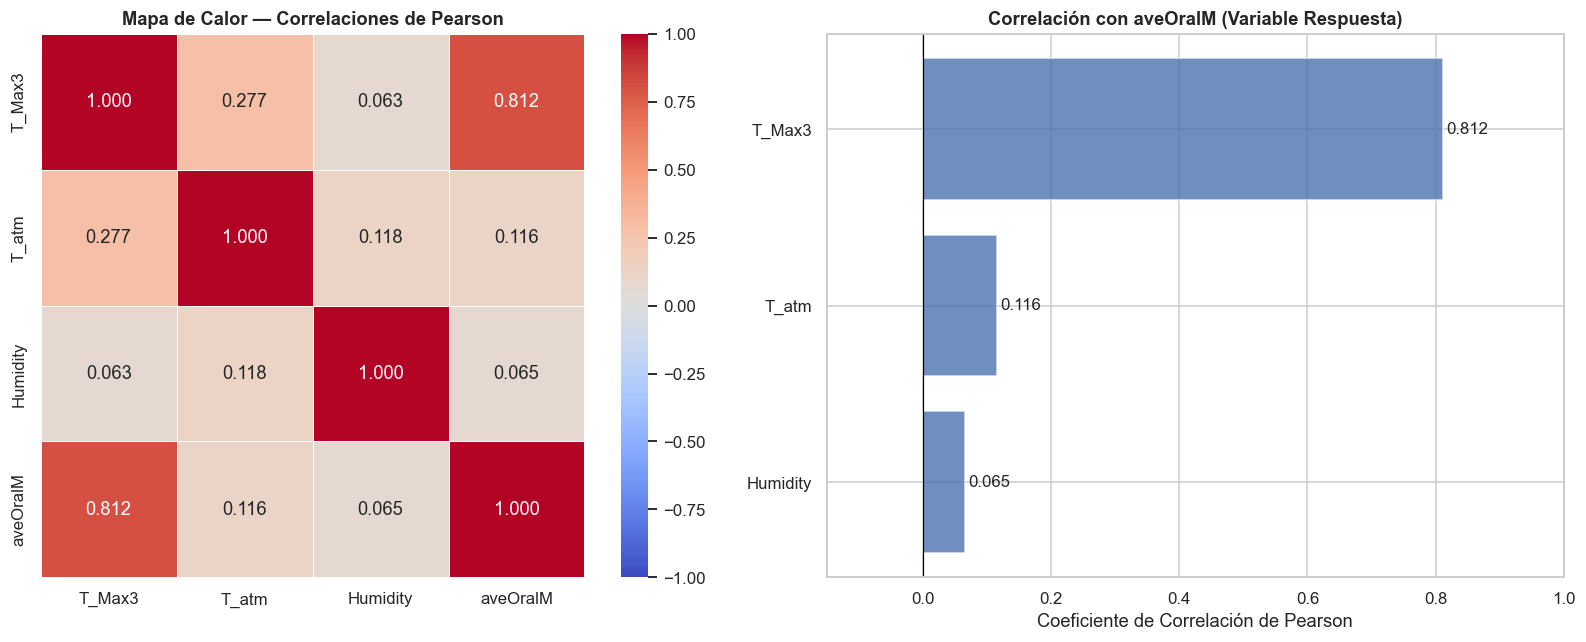

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap de correlación
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Mapa de Calor — Correlaciones de Pearson', fontweight='bold', fontsize=12)

# Barras de correlación con aveOralM
corr_resp = corr['aveOralM'].drop('aveOralM').sort_values()
colors_bar = ['#C44E52' if v < 0 else '#4C72B0' for v in corr_resp]
axes[1].barh(corr_resp.index, corr_resp.values, color=colors_bar, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, (idx, v) in enumerate(corr_resp.items()):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005, i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=11)
axes[1].set_title('Correlación con aveOralM (Variable Respuesta)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Coeficiente de Correlación de Pearson')
axes[1].set_xlim(-0.15, 1.0)

plt.tight_layout()
plt.show()


| Variable | Correlación con `aveOralM` | Interpretación |
|---|---|---|
| `T_Max3` | ~0.812 | **Correlación positiva fuerte**. Es el predictor más importante. |
| `T_atm` | ~0.116 | Correlación positiva muy débil. Aporte marginal al modelo. |
| `Humidity` | ~0.065 | Correlación positiva muy débil. Aporte mínimo. |

Por lo tanto: 

`T_Max3` es el predictor dominante con una correlación de aproximadamente **0.81** con la temperatura oral. Esto es esperable, ya que mide directamente la temperatura facial del mismo paciente. Claramente esta variable es predictor más importante, pues las variables `T_atm` y `Humidity` tendrán un aporte insignificante para la contrucción del modelo.


# Construcción y Evaluación de Modelos de Regresión

Se construyen tres modelos de regresión con todas las variables disponibles (`T_Max3`, `T_atm`, `Humidity`):
1. **Regresión lineal múltiple de efectos principales**
2. **Regresión lineal múltiple con interacciones**
3. **Regresión polinómica de grado 2**

Cada modelo se evalúa mediante **validación cruzada k-folds** con **k = 10**, comparando el **coeficiente de determinación (R²)** y el **Error Cuadrático Medio (RMSE)**.

In [44]:
# Preparación de variables
X = df_clean[['T_Max3', 'T_atm', 'Humidity']].values
y = df_clean['aveOralM'].values

# Configuración del k-fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f'Observaciones para modelado: {len(y)}')
print(f'Predictoras: T_Max3, T_atm, Humidity')
print(f'Variable respuesta: aveOralM')
print(f'Validación cruzada: k = 10')

Observaciones para modelado: 1007
Predictoras: T_Max3, T_atm, Humidity
Variable respuesta: aveOralM
Validación cruzada: k = 10


# Modelo 1: Regresión Lineal Múltiple de Efectos Principales

Este modelo asume una relación lineal entre cada variable predictora y la variable respuesta, sin considerar interacciones entre ellas:

$$\hat{y} = \beta_0 + \beta_1 \cdot T\_Max3 + \beta_2 \cdot T\_atm + \beta_3 \cdot Humidity + \varepsilon$$

In [46]:
modelo1 = LinearRegression()

# Cross-validation
r2_m1   = cross_val_score(modelo1, X, y, cv=kf, scoring='r2')
mse_m1  = cross_val_score(modelo1, X, y, cv=kf,
                           scoring='neg_mean_squared_error')
rmse_m1 = np.sqrt(-mse_m1)

# Ajuste en todo el dataset para ver coeficientes
modelo1.fit(X, y)

print('=== Modelo 1: Regresión Lineal Múltiple (Efectos Principales) ===')
print(f'Intercepto : {modelo1.intercept_:.4f}')
print(f'β_T_Max3   : {modelo1.coef_[0]:.4f}')
print(f'β_T_atm    : {modelo1.coef_[1]:.4f}')
print(f'β_Humidity : {modelo1.coef_[2]:.4f}')
print(f'\nEcuación: aveOralM = {modelo1.intercept_:.4f}'
      f' + {modelo1.coef_[0]:.4f}·T_Max3'
      f' + {modelo1.coef_[1]:.4f}·T_atm'
      f' + {modelo1.coef_[2]:.4f}·Humidity')
print(f'\nResultados K-Fold (k=10):')
print(f'  R²   por fold: {np.round(r2_m1, 4)}')
print(f'  R² medio      : {r2_m1.mean():.4f} ± {r2_m1.std():.4f}')
print(f'  RMSE medio    : {rmse_m1.mean():.4f} ± {rmse_m1.std():.4f}')

=== Modelo 1: Regresión Lineal Múltiple (Efectos Principales) ===
Intercepto : 8.4325
β_T_Max3   : 0.8232
β_T_atm    : -0.0437
β_Humidity : 0.0010

Ecuación: aveOralM = 8.4325 + 0.8232·T_Max3 + -0.0437·T_atm + 0.0010·Humidity

Resultados K-Fold (k=10):
  R²   por fold: [0.6014 0.5775 0.5053 0.6896 0.5957 0.7178 0.7508 0.746  0.674  0.6187]
  R² medio      : 0.6477 ± 0.0765
  RMSE medio    : 0.2778 ± 0.0192


# Modelo 2: Regresión Lineal Múltiple con Interacciones

Este modelo incorpora términos de interacción entre pares de variables predictoras, permitiendo que el efecto de una variable dependa del nivel de otra:

$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_{12} X_1 X_2 + \beta_{13} X_1 X_3 + \beta_{23} X_2 X_3 $$

In [47]:
# Crear términos de interacción manualmente
df_inter = df_clean[['T_Max3', 'T_atm', 'Humidity']].copy()
df_inter['T_Max3 × T_atm']    = df_clean['T_Max3'] * df_clean['T_atm']
df_inter['T_Max3 × Humidity'] = df_clean['T_Max3'] * df_clean['Humidity']
df_inter['T_atm × Humidity']  = df_clean['T_atm']  * df_clean['Humidity']
X_inter = df_inter.values

modelo2 = LinearRegression()

r2_m2   = cross_val_score(modelo2, X_inter, y, cv=kf, scoring='r2')
mse_m2  = cross_val_score(modelo2, X_inter, y, cv=kf,
                           scoring='neg_mean_squared_error')
rmse_m2 = np.sqrt(-mse_m2)

modelo2.fit(X_inter, y)
nombres = df_inter.columns.tolist()

print('=== Modelo 2: Regresión con Interacciones ===')
print(f'Intercepto : {modelo2.intercept_:.4f}')
for nom, coef in zip(nombres, modelo2.coef_):
    print(f'  {nom:25s}: {coef:.6f}')
print(f'\nResultados K-Fold (k=10):')
print(f'  R²   por fold: {np.round(r2_m2, 4)}')
print(f'  R² medio      : {r2_m2.mean():.4f} ± {r2_m2.std():.4f}')
print(f'  RMSE medio    : {rmse_m2.mean():.4f} ± {rmse_m2.std():.4f}')

=== Modelo 2: Regresión con Interacciones ===
Intercepto : 38.8802
  T_Max3                   : -0.053866
  T_atm                    : -1.245129
  Humidity                 : -0.014600
  T_Max3 × T_atm           : 0.034684
  T_Max3 × Humidity        : 0.001325
  T_atm × Humidity         : -0.001353

Resultados K-Fold (k=10):
  R²   por fold: [0.593  0.5778 0.4935 0.6907 0.6067 0.7137 0.7637 0.7519 0.675  0.6213]
  R² medio      : 0.6487 ± 0.0808
  RMSE medio    : 0.2769 ± 0.0188


# Modelo 3: Regresión Polinómica de Grado 2

Este modelo amplía las predictoras con términos cuadráticos e interacciones cuadráticas, capturando posibles relaciones no lineales:

$$y = \beta_0 + \sum_i \beta_i X_i + \sum_i \beta_{ii} X_i^2 + \sum_{i<j} \beta_{ij} X_i X_j$$

In [48]:
modelo3 = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('linreg', LinearRegression())
])

r2_m3   = cross_val_score(modelo3, X, y, cv=kf, scoring='r2')
mse_m3  = cross_val_score(modelo3, X, y, cv=kf,
                           scoring='neg_mean_squared_error')
rmse_m3 = np.sqrt(-mse_m3)

modelo3.fit(X, y)
poly_feat = modelo3.named_steps['poly']
feat_names = poly_feat.get_feature_names_out(['T_Max3', 'T_atm', 'Humidity'])
coefs_m3   = modelo3.named_steps['linreg'].coef_

print('=== Modelo 3: Regresión Polinómica Grado 2 ===')
print(f'Número de términos generados: {len(feat_names)}')
print(f'Intercepto : {modelo3.named_steps["linreg"].intercept_:.4f}')
for fn, cv in zip(feat_names, coefs_m3):
    print(f'  {fn:30s}: {cv:.6f}')
print(f'\nResultados K-Fold (k=10):')
print(f'  R²   por fold: {np.round(r2_m3, 4)}')
print(f'  R² medio      : {r2_m3.mean():.4f} ± {r2_m3.std():.4f}')
print(f'  RMSE medio    : {rmse_m3.mean():.4f} ± {rmse_m3.std():.4f}')

=== Modelo 3: Regresión Polinómica Grado 2 ===
Número de términos generados: 9
Intercepto : 288.0057
  T_Max3                        : -15.038964
  T_atm                         : 0.624593
  Humidity                      : 0.000407
  T_Max3^2                      : 0.221340
  T_Max3 T_atm                  : -0.010021
  T_Max3 Humidity               : 0.001032
  T_atm^2                       : -0.004894
  T_atm Humidity                : -0.001546
  Humidity^2                    : 0.000015

Resultados K-Fold (k=10):
  R²   por fold: [0.6449 0.6013 0.5997 0.6781 0.6226 0.7423 0.8205 0.8039 0.6777 0.6613]
  R² medio      : 0.6852 ± 0.0750
  RMSE medio    : 0.2611 ± 0.0145


# Comparación de Modelos mediante Validación K-Folds (k = 10)

In [49]:
resultados = pd.DataFrame({
    'Modelo': [
        'Modelo 1: Lineal (Efectos Principales)',
        'Modelo 2: Lineal con Interacciones',
        'Modelo 3: Polinómico Grado 2'
    ],
    'R² Medio': [r2_m1.mean(), r2_m2.mean(), r2_m3.mean()],
    'R² Std':   [r2_m1.std(),  r2_m2.std(),  r2_m3.std()],
    'RMSE Medio': [rmse_m1.mean(), rmse_m2.mean(), rmse_m3.mean()],
    'RMSE Std':   [rmse_m1.std(),  rmse_m2.std(),  rmse_m3.std()],
})
resultados = resultados.set_index('Modelo')
print('=== Tabla Comparativa de Modelos (Validación k=10) ===')
resultados.round(5)

=== Tabla Comparativa de Modelos (Validación k=10) ===


,R² Medio,R² Std,RMSE Medio,RMSE Std
Modelo,,,,
Modelo 1: Lineal (Efectos Principales),0.64768,0.07652,0.27777,0.01915
Modelo 2: Lineal con Interacciones,0.64872,0.08080,0.27693,0.01881
Modelo 3: Polinómico Grado 2,0.68524,0.07498,0.26106,0.01453


# Análisis Final y Conclusiones

Recordemos que a menor RMSE, el modelo es más preciso y que el valor de $R^2$ entre más cerca de 1, significa que hay una mejor relación lineal con los datos que se ajustan al modelo. Así, concluimos que...

El modelo más preciso para esta predicción es el modelo 3 que corresponde a un modelo polinómico de grado 2, aunque la diferencia entre los tres modelos es muy pequeña.

1. **_Modelo 1 (Efectos Principales):_** Es el más simple y ya captura la mayor parte de la variabilidad explicable (~65% del R²). La relación entre temperatura termográfica y oral es predominantemente lineal. Este modelo sigue el principio de parsimonia y es fácil de interpretar.

2. **_Modelo 2 (Interacciones):_** Añadir los términos de interacción mejora el R² y reduce ligeramente el RMSE. Esto sugiere que existe alguna interacción débil entre las variables de T_atm y Humidity, y la variable aveOralM, pero su aporte práctico es pequeño.

3. **Modelo 3 (Polinómico Grado 2):** Obtiene el mejor R² y el menor RMSE gracias a la inclusión de términos cuadráticos que capturan curvaturas en las relaciones.